In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [2]:
TRAIN_PATH = "../data/classification/train"
VAL_PATH = "../data/classification/val"

In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    VAL_PATH,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 1750 images belonging to 25 classes.
Found 375 images belonging to 25 classes.


In [4]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [5]:
for layer in base_model.layers:
    layer.trainable = False

In [6]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)

outputs = Dense(train_generator.num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=outputs)

In [7]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [8]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    verbose=1
)

Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.0583 - loss: 3.5089 - val_accuracy: 0.1893 - val_loss: 2.9943
Epoch 2/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.1491 - loss: 3.0087 - val_accuracy: 0.2853 - val_loss: 2.7740
Epoch 3/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.2120 - loss: 2.7883 - val_accuracy: 0.4187 - val_loss: 2.5553
Epoch 4/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.2903 - loss: 2.5783 - val_accuracy: 0.4213 - val_loss: 2.3536
Epoch 5/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.3463 - loss: 2.4073 - val_accuracy: 0.4667 - val_loss: 2.1774
Epoch 6/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.3869 - loss: 2.2378 - val_accuracy: 0.4987 - val_loss: 2.0322
Epoch 7/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.4303 - loss: 2.0729 - val_accuracy: 0.5307 - val_loss: 1.9153
Epoch 8/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.4411 - loss: 2.0098 - val_accuracy: 0.5573 - val_loss:

In [9]:
model.save("../models/mobilenet_model.h5")
print("MobileNet Model Saved ✅")

MobileNet Model Saved ✅


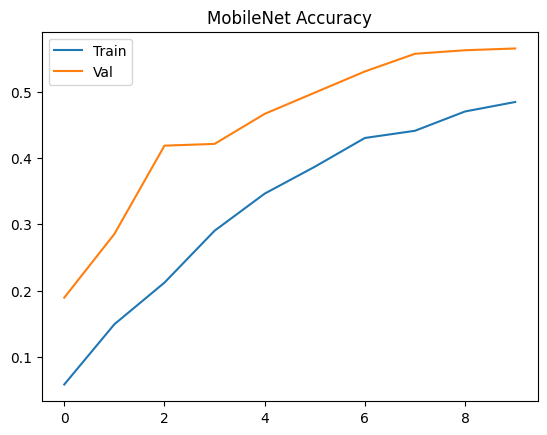

In [10]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("MobileNet Accuracy")
plt.legend(["Train","Val"])
plt.show()